In [7]:
from torch.utils.data import DataLoader, TensorDataset, Dataset
from data import TensorDataset2D, generate_gassian_bimodal
import torch
import matplotlib.pyplot as plt


In [32]:
def generate_synthetic_data(num_samples=1000, mean_0=(0, 0), mean_1=(5, 5), std_dev1=1.0, std_dev2=1.0):
    # Generate synthetic data for two classes
    class_0 = std_dev1*torch.randn(num_samples // 2, 2) + torch.tensor(mean_0)  # Class 0 centered at mean_0
    class_1 = std_dev2*torch.randn(num_samples // 2, 2) + torch.tensor(mean_1)  # Class 1 centered at mean_1
    
    data = torch.cat([class_0, class_1], dim=0)
    labels = torch.cat([torch.zeros(num_samples // 2), torch.ones(num_samples // 2)], dim=0)
    
    return data, labels

In [38]:
data, labels = generate_synthetic_data(50000, mean_0=(0, -1), mean_1=(0, 1), std_dev1=0.1, std_dev2=0.1)

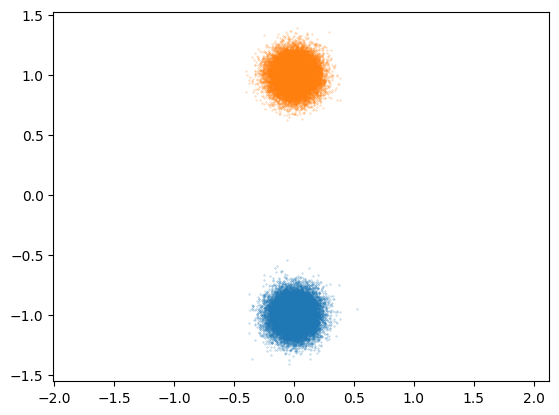

In [41]:
import matplotlib.pyplot as plt

x = data
y = labels

class0 = y == 0
class1 = y == 1

plt.scatter(x[class0, 0], x[class0, 1], s = 0.1, alpha = 0.5)
plt.scatter(x[class1, 0], x[class1, 1], s = 0.1, alpha = 0.5)
plt.axis('equal')
plt.show()

In [2]:
data = generate_gassian_bimodal(num_samples=50000, mean_0=(0, -1), mean_1=(0, 1), std_dev1=0.1, std_dev2=0.1)

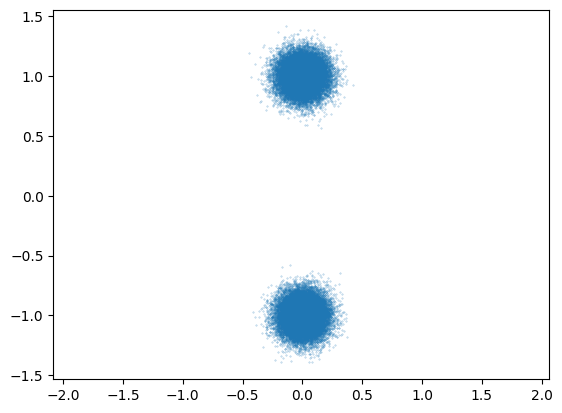

In [12]:
plt.scatter(data[:, 0], data[:, 1], s = 0.1, alpha = 0.5)
plt.axis('equal')   
plt.show()

In [ ]:
def generate_bimodal_uniform_rectangular(num_samples=1000, limits_0=((-3, -1), (-1, 1)), limits_1=((1, 3), (-1, 1))):

    x_0 = torch.rand(num_samples // 2) * (limits_0[0][1] - limits_0[0][0]) + limits_0[0][0]
    y_0 = torch.rand(num_samples // 2) * (limits_0[1][1] - limits_0[1][0]) + limits_0[1][0]
    class_0 = torch.stack((x_0, y_0), dim=1)

    x_1 = torch.rand(num_samples // 2) * (limits_1[0][1] - limits_1[0][0]) + limits_1[0][0]
    y_1 = torch.rand(num_samples // 2) * (limits_1[1][1] - limits_1[1][0]) + limits_1[1][0]
    class_1 = torch.stack((x_1, y_1), dim=1)

    data = torch.cat([class_0, class_1], dim=0)
    return data

In [19]:
data = generate_bimodal_uniform_rectangular(num_samples=50000, limits_0=((-3, -1), (-1, 1)), limits_1=((1, 3), (-1, 1)))

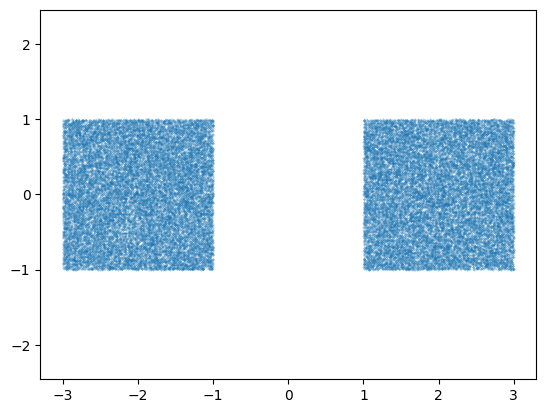

In [20]:
plt.scatter(data[:, 0], data[:, 1], s = 0.1, alpha = 0.5)
plt.axis('equal')   
plt.show()

In [117]:
def generate_circular_bimodal(num_samples=1000, center_0=(0, 0), center_1=(0, 0), radius_0=1.0, radius_1=2.0, std_dev=0.1):
    angles_0 = torch.rand(num_samples // 2) * 2 * torch.pi
    class_0 = torch.stack((radius_0 * torch.cos(angles_0), radius_0 * torch.sin(angles_0)), dim=1) + std_dev * torch.randn(num_samples // 2, 2) + torch.tensor(center_0)

    angles_1 = torch.rand(num_samples // 2) * 2 * torch.pi
    class_1 = torch.stack((radius_1 * torch.cos(angles_1), radius_1 * torch.sin(angles_1)), dim=1) + std_dev * torch.randn(num_samples // 2, 2) + torch.tensor(center_1)

    data = torch.cat([class_0, class_1], dim=0)
    return data

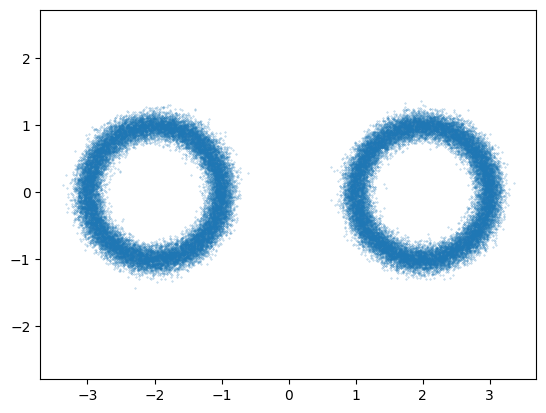

In [118]:
data = generate_circular_bimodal(num_samples=50000, center_0=(-2, 0), center_1=(2, 0), radius_0=1.0, radius_1=1.0, std_dev=0.1)
plt.scatter(data[:, 0], data[:, 1], s = 0.1, alpha = 0.5)
plt.axis('equal')   
plt.show()

In [49]:
def generate_circular(num_samples=1000, center=(0, 0), radius = 1.0, std_dev=0.1):

    angles = torch.rand(num_samples // 2) * 2 * torch.pi
    data = torch.stack((radius * torch.cos(angles), radius * torch.sin(angles)), dim=1) + std_dev * torch.randn(num_samples // 2, 2) + torch.tensor(center)

    return data

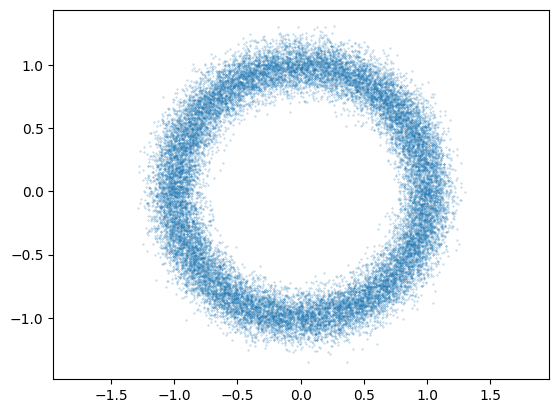

In [65]:
data = generate_circular(num_samples=50000, radius=1.0, std_dev=0.1)
plt.scatter(data[:, 0], data[:, 1], s = 0.1, alpha = 0.5)
plt.axis('equal')   
plt.show()

In [72]:
TensorDataset(data)

In [80]:
import torch
import matplotlib.pyplot as plt
import torch.distributions as D

In [81]:
# Mixture weights (2 components, equal probability)
mix = D.Categorical(torch.ones(2))

# Means: shape (num_components, dim)
means = torch.tensor([
    [-1., -1.],
    [ 1.,  1.]
])

# Standard deviations (example: both isotropic with std=0.5)
stds = torch.ones(2, 2) * 0.5

# Component distribution (2D Gaussians with diagonal covariance)
comp = D.Independent(
    D.Normal(means, stds),
    1
)

# Gaussian Mixture Model
z_dist = D.MixtureSameFamily(mix, comp)

In [115]:
z_dist.log_prob(torch.randn(10, 2)).sum(dim=-1)

tensor(-39.3955)

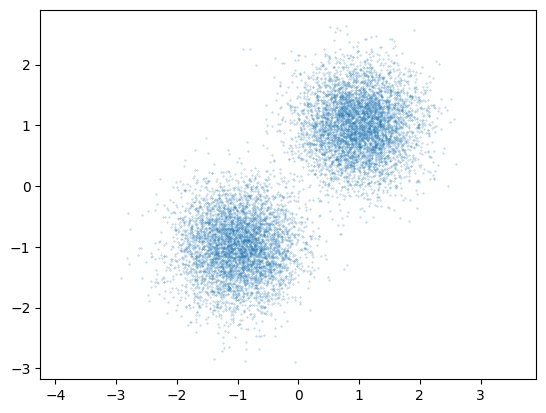

In [95]:
#plot the distribution
samples = z_dist.sample((10000,))
plt.scatter(samples[:, 0], samples[:, 1], s = 0.1, alpha = 0.5)
plt.axis('equal')
plt.show()

In [1]:
import datasets
dataset = datasets.load_dataset("hepmass", split="train[:20000]")

ModuleNotFoundError: No module named 'datasets'